# Nigeria MICS preprocessing — ADM1 version

This notebook preprocesses Nigeria MICS household/person data, attaches ADM1 administrative variables, and merges ADM1 climate medians from:

`/data/shared/fsibilla/DATA_PROCESSING/nga_mics/climate_medians.csv`

Spatial resolution is intentionally **ADM1 only** for MICS.

In [1]:
from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

from shapely import wkt
from shapely.geometry.base import BaseGeometry

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 120)

In [2]:
# Paths
BASE_MICS = Path("/data/shared/fsibilla/wfp-da4hd/DATA/in/nga/Nigeria MICS6 SPSS Datasets/Nigeria MICS6 SPSS Datasets")
BASE_ADMIN = Path("/data/shared/fsibilla/wfp-da4hd/DATA/out/nga")
BASE_OUT = Path("/data/shared/fsibilla/DATA_PROCESSING/nga_mics")

HH_PATH = BASE_MICS / "hh.sav"
HL_PATH = BASE_MICS / "hl.sav"
ADMINS_PATH = BASE_ADMIN / "complete_nga.csv"
CLIMATE_MEDIANS_PATH = BASE_OUT / "climate_medians.csv"

FINAL_CSV_PATH = BASE_OUT / "full.csv"

print("Household SPSS exists:", HH_PATH.exists(), HH_PATH)
print("Household-list SPSS exists:", HL_PATH.exists(), HL_PATH)
print("Admin/geovariables exists:", ADMINS_PATH.exists(), ADMINS_PATH)
print("Climate medians exists:", CLIMATE_MEDIANS_PATH.exists(), CLIMATE_MEDIANS_PATH)
print("Final output path:", FINAL_CSV_PATH)

Household SPSS exists: True /data/shared/fsibilla/wfp-da4hd/DATA/in/nga/Nigeria MICS6 SPSS Datasets/Nigeria MICS6 SPSS Datasets/hh.sav
Household-list SPSS exists: True /data/shared/fsibilla/wfp-da4hd/DATA/in/nga/Nigeria MICS6 SPSS Datasets/Nigeria MICS6 SPSS Datasets/hl.sav
Admin/geovariables exists: True /data/shared/fsibilla/wfp-da4hd/DATA/out/nga/complete_nga.csv
Climate medians exists: True /data/shared/fsibilla/DATA_PROCESSING/nga_mics/climate_medians.csv
Final output path: /data/shared/fsibilla/DATA_PROCESSING/nga_mics/full.csv


## Helper functions

In [3]:
def normalize_name(x):
    """
    Normalize administrative names for robust matching.
    """
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.replace("&", " and ").replace("-", " ")
    s = re.sub(r"[^a-z0-9]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


ADM1_ALIASES = {
    "fct": "fct abuja",
    "federal capital territory": "fct abuja",
    "abuja": "fct abuja",
    "fct abuja": "fct abuja",
    "nasarawa state": "nasarawa",
    "nassarawa": "nasarawa",
}


def adm1_key(x):
    key = normalize_name(x)
    return ADM1_ALIASES.get(key, key)


def clean_code(x):
    """
    Make admin codes comparable.
    """
    if pd.isna(x):
        return ""
    s = str(x).strip()
    s = re.sub(r"\.0$", "", s)
    s = s.replace(" ", "")
    return s.upper()


def parse_geometry(x):
    """
    Convert WKT text to shapely geometry. If already geometry, keep it.
    """
    if isinstance(x, BaseGeometry):
        return x
    if pd.isna(x):
        return None
    if isinstance(x, str):
        try:
            return wkt.loads(x)
        except Exception:
            return None
    return None


def show_shape(name, data):
    print(f"{name}: {data.shape[0]} rows, {data.shape[1]} columns")


def make_household_id(df, hh1_col="HH1", hh2_col="HH2"):
    """
    Stable household id from cluster and household number.
    Kept as string to avoid accidental collisions from simple concatenation.
    """
    hh1 = pd.to_numeric(df[hh1_col], errors="coerce").astype("Int64").astype(str)
    hh2 = pd.to_numeric(df[hh2_col], errors="coerce").astype("Int64").astype(str)
    return hh1 + "_" + hh2


def first_existing_col(columns, candidates, required=True, label="column"):
    for c in candidates:
        if c in columns:
            return c
    if required:
        raise KeyError(f"Could not find {label}. Tried: {candidates}")
    return None

## Load and preprocess MICS household data

In [4]:
df_hh_raw = pd.read_spss(HH_PATH)

hh_cols = ["HH6", "HH7", "HH1", "HH2", "HH46", "HH48", "HC3", "WS4"]
df_hh = df_hh_raw[hh_cols].copy()

show_shape("Raw household data", df_hh)
display(df_hh.head())

Raw household data: 41532 rows, 8 columns


,HH6,HH7,HH1,HH2,HH46,HH48,HC3,WS4
0,URBAN,ABIA,1.0,1.0,COMPLETED,4.0,1.0,6.0
1,URBAN,ABIA,1.0,2.0,COMPLETED,2.0,1.0,5.0
2,URBAN,ABIA,1.0,3.0,COMPLETED,5.0,1.0,4.0
3,URBAN,ABIA,1.0,4.0,COMPLETED,4.0,45.0,15.0
4,URBAN,ABIA,1.0,5.0,COMPLETED,5.0,2.0,5.0


In [5]:
# Keep completed interviews only
completion = df_hh["HH46"].astype(str).str.upper().str.strip()
df_hh = df_hh[completion.eq("COMPLETED")].copy()

# Household id
df_hh["id"] = make_household_id(df_hh, "HH1", "HH2")

# Rename columns
df_hh = df_hh.rename(columns={
    "HH6": "sector",
    "HH7": "survey_adm1name",
    "HH48": "hh_size",
    "HC3": "rooms",
    "WS4": "water_source",
    "HH1": "psu",
})

# Keep useful household columns
df_hh = df_hh[["sector", "survey_adm1name", "id", "hh_size", "rooms", "water_source", "psu"]].copy()

# Numeric conversion
num_cols = ["hh_size", "rooms", "water_source", "psu"]
df_hh[num_cols] = df_hh[num_cols].apply(pd.to_numeric, errors="coerce")

# If there are duplicate household ids, aggregate numeric columns and keep first categorical fields
agg_dict = {
    "sector": "first",
    "survey_adm1name": "first",
    "hh_size": "mean",
    "rooms": "mean",
    "water_source": "mean",
    "psu": "first",
}

df_hh = (
    df_hh
    .sort_values("id")
    .groupby("id", as_index=False)
    .agg(agg_dict)
)

show_shape("Household data after filtering/aggregation", df_hh)
print("Unique survey ADM1 names:", df_hh["survey_adm1name"].nunique())
display(df_hh.head())

Household data after filtering/aggregation: 39632 rows, 7 columns
Unique survey ADM1 names: 37


,id,sector,survey_adm1name,hh_size,rooms,water_source,psu
0,1000_1,URBAN,KATSINA,13.0,3.0,70.0,1000.0
1,1000_10,URBAN,KATSINA,9.0,3.0,20.0,1000.0
2,1000_11,URBAN,KATSINA,10.0,2.0,10.0,1000.0
3,1000_12,URBAN,KATSINA,5.0,1.0,NaN,1000.0
4,1000_13,URBAN,KATSINA,5.0,2.0,NaN,1000.0


## Load and preprocess MICS household-list data

In [6]:
df_hl_raw = pd.read_spss(HL_PATH)

hl_cols = ["HL6", "HH6", "HH7", "HH1", "HH2", "ED5A", "wscoreMICS", "wscore"]
df_hl = df_hl_raw[hl_cols].copy()

show_shape("Raw household-list data", df_hl)
display(df_hl.head())

Raw household-list data: 207496 rows, 8 columns


,HL6,HH6,HH7,HH1,HH2,ED5A,wscoreMICS,wscore
0,46.0,URBAN,ABIA,1.0,1.0,PRIMARY,0.839976,0.820389
1,22.0,URBAN,ABIA,1.0,1.0,SENIOR SECONDARY,0.839976,0.820389
2,18.0,URBAN,ABIA,1.0,1.0,SENIOR SECONDARY,0.839976,0.820389
3,10.0,URBAN,ABIA,1.0,1.0,JUNIOR SECONDARY,0.839976,0.820389
4,45.0,URBAN,ABIA,1.0,2.0,SENIOR SECONDARY,0.695187,0.700122


In [7]:
df_hl["age"] = pd.to_numeric(df_hl["HL6"], errors="coerce")
is_adult = df_hl["age"].ge(17)

# Map education levels to numeric values between 0 and 1.
education_mapping = {
    "DK": 0.00,
    "NO RESPONSE": 0.00,
    None: 0.00,
    float("nan"): 0.00,
    "ECCDE": 0.10,
    "PRIMARY": 0.30,
    "JUNIOR SECONDARY": 0.45,
    "SENIOR SECONDARY": 0.60,
    "SECONDARY TECHNICAL": 0.65,
    "VEI/IEI": 0.75,
    "HIGHER/TERTIARY": 1.00,
}

df_hl["education_numeric"] = df_hl["ED5A"].map(education_mapping).fillna(0)
df_hl["id"] = make_household_id(df_hl, "HH1", "HH2")

df_hl["wscore"] = pd.to_numeric(df_hl["wscore"], errors="coerce")
df_hl["wscoreMICS"] = pd.to_numeric(df_hl["wscoreMICS"], errors="coerce")

adult_mean_edu = (
    df_hl.loc[is_adult]
         .groupby("id")["education_numeric"]
         .mean()
         .rename("avg_adult_education")
         .reset_index()
)

hh_wscore = (
    df_hl.groupby("id", as_index=False)[["wscore", "wscoreMICS"]]
         .mean()
)

df_household_scores = hh_wscore.merge(adult_mean_edu, on="id", how="left")

show_shape("Household score/education data", df_household_scores)
display(df_household_scores.head())

Household score/education data: 39632 rows, 4 columns


,id,wscore,wscoreMICS,avg_adult_education
0,1000_1,-0.184929,-0.129691,0.45
1,1000_10,0.959485,1.123165,0.60
2,1000_11,0.152752,0.217269,0.15
3,1000_12,-0.730019,-0.709270,0.15
4,1000_13,-0.188106,-0.105898,0.00


## Merge household-level MICS variables

In [8]:
before = len(df_hh)

df = df_hh.merge(df_household_scores, on="id", how="inner")

after = len(df)
print("Rows before household/person merge:", before)
print("Rows after household/person merge:", after)

# Derived variables
df["space_per_person"] = df["rooms"] / df["hh_size"].replace(0, np.nan)
df["adm1_key"] = df["survey_adm1name"].map(adm1_key)

show_shape("Merged MICS household dataset", df)
display(df.head())

Rows before household/person merge: 39632
Rows after household/person merge: 39632
Merged MICS household dataset: 39632 rows, 12 columns


,id,sector,survey_adm1name,hh_size,rooms,water_source,psu,wscore,wscoreMICS,avg_adult_education,space_per_person,adm1_key
0,1000_1,URBAN,KATSINA,13.0,3.0,70.0,1000.0,-0.184929,-0.129691,0.45,0.230769,katsina
1,1000_10,URBAN,KATSINA,9.0,3.0,20.0,1000.0,0.959485,1.123165,0.60,0.333333,katsina
2,1000_11,URBAN,KATSINA,10.0,2.0,10.0,1000.0,0.152752,0.217269,0.15,0.200000,katsina
3,1000_12,URBAN,KATSINA,5.0,1.0,NaN,1000.0,-0.730019,-0.709270,0.15,0.200000,katsina
4,1000_13,URBAN,KATSINA,5.0,2.0,NaN,1000.0,-0.188106,-0.105898,0.00,0.400000,katsina


## Merge ADM1 geovariables/admin data

MICS is kept at ADM1 resolution. Any ADM2 detail in the admin file is collapsed to ADM1 before merging.

In [9]:
adms_raw = pd.read_csv(ADMINS_PATH)
adms = adms_raw.copy()

show_shape("Raw admin/geovariables", adms)
print("Admin columns:")
print(adms.columns.tolist())
display(adms.head())

Raw admin/geovariables: 22106 rows, 58 columns
Admin columns:
['Unnamed: 0_x', 'hhid', 'Code_adm1', 'Name_adm1', 'geometry_adm1', 'geometry_adm2', 'Code_adm1.1', 'Name_adm2', 'Unnamed: 0_y', 'asset1', 'asset2', 'asset3', 'asset6', 'asset7', 'asset8', 'education2', 'food group1', 'food group2', 'food group3', 'food group4', 'food group5', 'food group6', 'food group7', 'food group8', 'housing1', 'housing2', 'housing4', 'labour1', 'labour2', 'labour4', 'labour5', 'r3q', 'rfh_avg', 'vim_avg', 'Unnamed: 0', 'va_ai', 'fol_ai', 'vb12_ai', 'fe_ai', 'zn_ai', 'mimi_simple', 'survey_id', 'zone', 'state', 'lga', 'sector', 'ea', 'average_edu_adults', 'household_income', 'log_income', 'log_nf_exp', 'vim_avg_1', 'rfh_avg_1', 'r3q_1', 'entropy_1', 'entropy_2', 'rwi_1', 'rwi_2']


,Unnamed: 0_x,hhid,Code_adm1,Name_adm1,geometry_adm1,geometry_adm2,Code_adm1.1,Name_adm2,Unnamed: 0_y,asset1,asset2,asset3,asset6,asset7,asset8,education2,food group1,food group2,food group3,food group4,food group5,food group6,food group7,food group8,housing1,housing2,housing4,labour1,labour2,labour4,labour5,r3q,rfh_avg,vim_avg,Unnamed: 0,va_ai,fol_ai,vb12_ai,fe_ai,zn_ai,mimi_simple,survey_id,zone,state,lga,sector,ea,average_edu_adults,household_income,log_income,log_nf_exp,vim_avg_1,rfh_avg_1,r3q_1,entropy_1,entropy_2,rwi_1,rwi_2
0,0,101001,65698,Abia,"POLYGON ((7.2515 5.1947, 7.2603 5.194, 7.2647 ...","POLYGON ((7.3148 5.088, 7.3781 5.057, 7.3796 5...",1000060,Aba North,6770,1.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,100.0,39.153,0.605,6688,281.922669,129.976402,4.073249,8.862358,5.417795,0.604411,NGA_2018_LSS_v01_M,4,1,101,1,186,14.0,0.0,0.000000,10.005186,0.736416,68.843727,102.521949,3.541932,3.610818,0.253542,1.31275
1,1,101002,65698,Abia,"POLYGON ((7.2515 5.1947, 7.2603 5.194, 7.2647 ...","POLYGON ((7.3148 5.088, 7.3781 5.057, 7.3796 5...",1000060,Aba North,6771,1.0,1.0,0.0,0.0,0.0,1.0,6.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,0.0,1.0,1.0,0.0,100.0,39.153,0.605,6689,558.278649,282.146729,6.838950,16.190006,11.045542,0.944554,NGA_2018_LSS_v01_M,4,1,101,1,186,14.5,2300000.0,14.648420,10.868587,0.736416,68.843727,102.521949,3.541932,3.610818,0.253542,1.31275
2,2,101003,65698,Abia,"POLYGON ((7.2515 5.1947, 7.2603 5.194, 7.2647 ...","POLYGON ((7.3148 5.088, 7.3781 5.057, 7.3796 5...",1000060,Aba North,6772,0.0,1.0,0.0,0.0,0.0,0.0,4.3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,100.0,39.153,0.605,6690,879.510728,419.395804,4.160046,22.185849,12.825437,0.998088,NGA_2018_LSS_v01_M,4,1,101,1,186,0.0,0.0,0.000000,8.476580,0.736416,68.843727,102.521949,3.541932,3.610818,0.253542,1.31275
3,3,101004,65698,Abia,"POLYGON ((7.2515 5.1947, 7.2603 5.194, 7.2647 ...","POLYGON ((7.3148 5.088, 7.3781 5.057, 7.3796 5...",1000060,Aba North,6773,1.0,1.0,1.0,0.0,0.0,1.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,100.0,39.153,0.605,6691,130.957418,94.723946,1.301092,5.808434,3.100635,0.371998,NGA_2018_LSS_v01_M,4,1,101,1,186,13.5,50000.0,10.819798,10.740757,0.736416,68.843727,102.521949,3.541932,3.610818,0.253542,1.31275
4,4,101005,65698,Abia,"POLYGON ((7.2515 5.1947, 7.2603 5.194, 7.2647 ...","POLYGON ((7.3148 5.088, 7.3781 5.057, 7.3796 5...",1000060,Aba North,6774,0.0,1.0,0.0,0.0,0.0,0.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,100.0,39.153,0.605,6692,190.416231,94.518641,1.771824,6.477938,3.668086,0.460280,NGA_2018_LSS_v01_M,4,1,101,1,186,12.0,0.0,0.000000,8.425297,0.736416,68.843727,102.521949,3.541932,3.610818,0.253542,1.31275


In [10]:
ADM1_NAME_COL = first_existing_col(adms.columns, ["Name_adm1", "adm1Name", "ADM1_NAME", "adm1name"], label="ADM1 name column in admin file")
ADM1_CODE_COL = first_existing_col(adms.columns, ["Code_adm1", "adm1Code", "ADM1_CODE", "adm1code"], required=False, label="ADM1 code column in admin file")
GEOM_COL = first_existing_col(adms.columns, ["Geometry_Adm1", "geometry_adm1", "adm1Geometry", "adm1geometry"], required=False, label="ADM1 geometry column in admin file")

print("ADM1_NAME_COL:", ADM1_NAME_COL)
print("ADM1_CODE_COL:", ADM1_CODE_COL)
print("GEOM_COL:", GEOM_COL)

adms["adm1_key"] = adms[ADM1_NAME_COL].map(adm1_key)

if ADM1_CODE_COL is not None:
    adms["adm1code"] = adms[ADM1_CODE_COL].apply(clean_code)
else:
    adms["adm1code"] = ""

if GEOM_COL is not None:
    adms["adm1geometry"] = adms[GEOM_COL].apply(parse_geometry)
else:
    adms["adm1geometry"] = None

# Variables to attach from the admin/geovariables file if present.
admin_value_cols = [
    c for c in ["rwi_1", "entropy_1", "RWI_1", "Entropy_1"]
    if c in adms.columns
]

# Standardize common variants
rename_admin_values = {}
if "RWI_1" in admin_value_cols:
    rename_admin_values["RWI_1"] = "rwi_1"
if "Entropy_1" in admin_value_cols:
    rename_admin_values["Entropy_1"] = "entropy_1"
adms = adms.rename(columns=rename_admin_values)
admin_value_cols = ["rwi_1" if c == "RWI_1" else "entropy_1" if c == "Entropy_1" else c for c in admin_value_cols]
admin_value_cols = list(dict.fromkeys(admin_value_cols))

# Collapse/deduplicate to one row per ADM1.
agg = {
    ADM1_NAME_COL: "first",
    "adm1code": "first",
    "adm1geometry": "first",
}
for c in admin_value_cols:
    agg[c] = "first"

adms_adm1 = (
    adms
    .sort_values("adm1_key")
    .groupby("adm1_key", as_index=False)
    .agg(agg)
    .rename(columns={ADM1_NAME_COL: "adm1name"})
)

show_shape("ADM1 admin lookup", adms_adm1)
display(adms_adm1.head())

ADM1_NAME_COL: Name_adm1
ADM1_CODE_COL: Code_adm1
GEOM_COL: geometry_adm1
ADM1 admin lookup: 37 rows, 6 columns


,adm1_key,adm1name,adm1code,adm1geometry,rwi_1,entropy_1
0,abia,Abia,65698,"POLYGON ((7.2515 5.1947, 7.2603 5.194, 7.2647 ...",0.253542,3.541932
1,adamawa,Adamawa,2211,"POLYGON ((11.5259 9.592, 11.614 9.4288, 11.637...",-0.369371,1.482853
2,akwa ibom,Akwa Ibom,2212,"POLYGON ((7.61 4.473, 7.6674 4.4976, 7.9346 4....",0.130178,2.991626
3,anambra,Anambra,2213,"POLYGON ((6.6644 6.5275, 6.6655 6.5228, 6.7168...",0.240468,3.218206
4,bauchi,Bauchi,65699,"POLYGON ((9.2247 11.3425, 9.1356 11.3078, 9.07...",-0.480614,2.196233


In [11]:
before = len(df)

df = df.merge(
    adms_adm1,
    on="adm1_key",
    how="left",
    validate="m:1",
    indicator="admin_merge_status",
)

after = len(df)
print("Rows before admin merge:", before)
print("Rows after admin merge:", after)
print("\nAdmin merge status:")
print(df["admin_merge_status"].value_counts())

unmatched_admin = (
    df.loc[df["admin_merge_status"].eq("left_only"), ["survey_adm1name", "adm1_key"]]
    .drop_duplicates()
    .sort_values("adm1_key")
)

print("\nUnmatched survey ADM1 names:", len(unmatched_admin))
display(unmatched_admin)

display(
    df[["survey_adm1name", "adm1name", "adm1code", "admin_merge_status"]]
    .drop_duplicates()
    .sort_values("adm1name")
)

Rows before admin merge: 39632
Rows after admin merge: 39632

Admin merge status:
admin_merge_status
both          39632
left_only         0
right_only        0
Name: count, dtype: int64

Unmatched survey ADM1 names: 0


,survey_adm1name,adm1_key


,survey_adm1name,adm1name,adm1code,admin_merge_status
2146,ABIA,Abia,65698,both
15764,FCT,Abuja,2221,both
200,ADAMAWA,Adamawa,2211,both
419,AKWA IBOM,Akwa Ibom,2212,both
10713,ANAMBRA,Anambra,2213,both
20278,BAUCHI,Bauchi,65699,both
17264,BAYELSA,Bayelsa,65700,both
17448,BENUE,Benue,2215,both
17644,BORNO,Borno,2216,both
27335,CROSS RIVER,Cross River,2217,both


## Merge ADM1 climate medians

The climate file may contain ADM1 and/or ADM2 columns, but this notebook deliberately collapses it to **one ADM1 row** before merging to MICS.

In [12]:
climate_raw = pd.read_csv(CLIMATE_MEDIANS_PATH)
climate = climate_raw.copy()

show_shape("Raw climate medians", climate)
print("Climate columns:")
print(climate.columns.tolist())
display(climate.head())

Raw climate medians: 764 rows, 12 columns
Climate columns:
['adm1Name', 'adm1Code', 'adm2Name', 'adm2Code', 'rfh_avg_2', 'r3q_2', 'vim_avg_2', 'rfh_avg_1', 'r3q_1', 'vim_avg_1', 'adm1Geometry', 'adm2Geometry']


,adm1Name,adm1Code,adm2Name,adm2Code,rfh_avg_2,r3q_2,vim_avg_2,rfh_avg_1,r3q_1,vim_avg_1,adm1Geometry,adm2Geometry
0,Abia,65698,Aba South,1000061,65.74165,97.39190,0.67450,70.61945,96.80935,0.7475,"POLYGON ((7.2515 5.1947, 7.2603 5.194, 7.2647 ...","POLYGON ((7.2999 5.0739, 7.3781 5.057, 7.3148 ..."
1,Abia,65698,Arochukwu,22592,72.17385,95.17385,0.79565,70.61945,96.80935,0.7475,"POLYGON ((7.2515 5.1947, 7.2603 5.194, 7.2647 ...","POLYGON ((7.635 5.6413, 7.6146 5.5721, 7.6415 ..."
2,Abia,65698,Bende,22593,73.12105,96.30785,0.79140,70.61945,96.80935,0.7475,"POLYGON ((7.2515 5.1947, 7.2603 5.194, 7.2647 ...","POLYGON ((7.4544 5.6631, 7.4915 5.5769, 7.5627..."
3,Abia,65698,Ikwuano,22594,74.94445,97.21580,0.76645,70.61945,96.80935,0.7475,"POLYGON ((7.2515 5.1947, 7.2603 5.194, 7.2647 ...","POLYGON ((7.5059 5.4129, 7.5098 5.2821, 7.5225..."
4,Abia,65698,Isiala Ngwa North,1000273,72.17775,98.56400,0.74830,70.61945,96.80935,0.7475,"POLYGON ((7.2515 5.1947, 7.2603 5.194, 7.2647 ...","POLYGON ((7.291 5.3233, 7.3511 5.3136, 7.4884 ..."


In [13]:
climate_adm1_name_col = first_existing_col(
    climate.columns,
    ["adm1Name", "Name_adm1", "ADM1_NAME", "adm1name", "clim_adm1name"],
    required=False,
    label="ADM1 name column in climate file",
)
climate_adm1_code_col = first_existing_col(
    climate.columns,
    ["adm1Code", "Code_adm1", "ADM1_CODE", "adm1code", "clim_adm1code"],
    required=False,
    label="ADM1 code column in climate file",
)
climate_adm1_geom_col = first_existing_col(
    climate.columns,
    ["adm1Geometry", "Geometry_Adm1", "geometry_adm1", "adm1geometry"],
    required=False,
    label="ADM1 geometry column in climate file",
)

print("climate_adm1_name_col:", climate_adm1_name_col)
print("climate_adm1_code_col:", climate_adm1_code_col)
print("climate_adm1_geom_col:", climate_adm1_geom_col)

if climate_adm1_name_col is not None:
    climate["clim_adm1name"] = climate[climate_adm1_name_col]
    climate["adm1_key"] = climate[climate_adm1_name_col].map(adm1_key)
else:
    climate["clim_adm1name"] = np.nan
    climate["adm1_key"] = ""

if climate_adm1_code_col is not None:
    climate["clim_adm1code"] = climate[climate_adm1_code_col].apply(clean_code)
else:
    climate["clim_adm1code"] = ""

if climate_adm1_geom_col is not None:
    climate["clim_adm1geometry"] = climate[climate_adm1_geom_col].apply(parse_geometry)
else:
    climate["clim_adm1geometry"] = None

# Use code if possible, otherwise use normalized ADM1 name.
climate["adm1_merge_key"] = climate["clim_adm1code"].where(
    climate["clim_adm1code"].astype(str).str.len().gt(0),
    climate["adm1_key"],
)

df["adm1_merge_key"] = df["adm1code"].apply(clean_code).where(
    df["adm1code"].apply(clean_code).astype(str).str.len().gt(0),
    df["adm1_key"],
)

print("Survey ADM1 merge keys:")
display(df[["survey_adm1name", "adm1name", "adm1code", "adm1_merge_key"]].drop_duplicates().sort_values("adm1_merge_key"))

print("Climate ADM1 merge keys:")
display(climate[["clim_adm1name", "clim_adm1code", "adm1_key", "adm1_merge_key"]].drop_duplicates().sort_values("adm1_merge_key").head(80))

climate_adm1_name_col: adm1Name
climate_adm1_code_col: adm1Code
climate_adm1_geom_col: adm1Geometry
Survey ADM1 merge keys:


,survey_adm1name,adm1name,adm1code,adm1_merge_key
200,ADAMAWA,Adamawa,2211,2211
419,AKWA IBOM,Akwa Ibom,2212,2212
10713,ANAMBRA,Anambra,2213,2213
17448,BENUE,Benue,2215,2215
17644,BORNO,Borno,2216,2216
27335,CROSS RIVER,Cross River,2217,2217
17957,DELTA,Delta,2218,2218
30261,EDO,Edo,2219,2219
15764,FCT,Abuja,2221,2221
34423,IMO,Imo,2222,2222


Climate ADM1 merge keys:


,clim_adm1name,clim_adm1code,adm1_key,adm1_merge_key
22,Adamawa,2211,adamawa,2211
43,Akwa Ibom,2212,akwa ibom,2212
74,Anambra,2213,anambra,2213
122,Benue,2215,benue,2215
145,Borno,2216,borno,2216
173,Cross River,2217,cross river,2217
189,Delta,2218,delta,2218
227,Edo,2219,edo,2219
16,Abuja,2221,fct abuja,2221
288,Imo,2222,imo,2222


In [14]:
# Select climate variables at ADM1 resolution.
# Preferred variables mirror the Yemen notebook.
preferred_adm1_climate_cols = ["rfh_avg_1", "r3q_1", "vim_avg_1"]

available_adm1_climate_cols = [c for c in preferred_adm1_climate_cols if c in climate.columns]

# If the file contains only non-standard numeric climate columns, keep them too, but avoid admin/id columns.
admin_like_patterns = re.compile(r"adm|code|name|geometry|geom|key", re.IGNORECASE)
extra_numeric_climate_cols = [
    c for c in climate.columns
    if c not in available_adm1_climate_cols
    and not admin_like_patterns.search(c)
    and pd.api.types.is_numeric_dtype(climate[c])
]

# Keep preferred columns first, then any extra numeric climate columns.
climate_value_cols = available_adm1_climate_cols + [c for c in extra_numeric_climate_cols if c not in available_adm1_climate_cols]

print("Climate value columns to attach:")
print(climate_value_cols)

if not climate_value_cols:
    print("WARNING: No numeric climate columns were detected for attachment.")

Climate value columns to attach:
['rfh_avg_1', 'r3q_1', 'vim_avg_1', 'rfh_avg_2', 'r3q_2', 'vim_avg_2']


In [15]:
# Collapse climate medians to one ADM1 row.
# Numeric climate variables are aggregated by median, preserving the ADM1 nature of the merge.
agg = {
    "clim_adm1name": "first",
    "clim_adm1code": "first",
    "clim_adm1geometry": "first",
}
for c in climate_value_cols:
    agg[c] = "median"

climate_adm1_lookup = (
    climate
    .dropna(subset=["adm1_merge_key"])
    .groupby("adm1_merge_key", as_index=False)
    .agg(agg)
)

show_shape("ADM1 climate lookup", climate_adm1_lookup)

print("Duplicated ADM1 merge keys after aggregation:", climate_adm1_lookup["adm1_merge_key"].duplicated().sum())
display(climate_adm1_lookup.head())

ADM1 climate lookup: 37 rows, 10 columns
Duplicated ADM1 merge keys after aggregation: 0


,adm1_merge_key,clim_adm1name,clim_adm1code,clim_adm1geometry,rfh_avg_1,r3q_1,vim_avg_1,rfh_avg_2,r3q_2,vim_avg_2
0,2211,Adamawa,2211,"POLYGON ((11.5259 9.592, 11.614 9.4288, 11.637...",18.3503,99.88270,0.42610,17.853400,99.98720,0.415050
1,2212,Akwa Ibom,2212,"POLYGON ((7.61 4.473, 7.6674 4.4976, 7.9346 4....",76.1965,93.48245,0.75045,74.597250,94.16370,0.756350
2,2213,Anambra,2213,"POLYGON ((6.6644 6.5275, 6.6655 6.5228, 6.7168...",60.9750,93.00140,0.65355,62.933325,93.43045,0.670525
3,2215,Benue,2215,"POLYGON ((7.4937 7.0745, 7.5358 6.9609, 7.5825...",44.3123,94.56530,0.61900,40.903750,94.69495,0.631250
4,2216,Borno,2216,"POLYGON ((11.7011 10.5942, 11.7229 10.5414, 11...",2.7303,100.34585,0.26470,3.129000,100.23090,0.263400


In [16]:
before = len(df)

df = df.merge(
    climate_adm1_lookup,
    on="adm1_merge_key",
    how="left",
    validate="m:1",
    indicator="climate_merge_status",
)

after = len(df)
print("Rows before climate merge:", before)
print("Rows after climate merge:", after)
if before != after:
    print("WARNING: row count changed!")

print("\nClimate merge status:")
print(df["climate_merge_status"].value_counts())

unmatched_climate = (
    df.loc[df["climate_merge_status"].eq("left_only"), ["survey_adm1name", "adm1name", "adm1code", "adm1_merge_key"]]
    .drop_duplicates()
    .sort_values("adm1_merge_key")
)

print("\nUnmatched ADM1 climate keys:", len(unmatched_climate))
display(unmatched_climate)

display(
    df[["survey_adm1name", "adm1name", "adm1code", "clim_adm1name", "clim_adm1code", "climate_merge_status"] + climate_value_cols]
    .drop_duplicates()
    .sort_values("adm1name")
    .head(80)
)

Rows before climate merge: 39632
Rows after climate merge: 39632

Climate merge status:
climate_merge_status
both          39632
left_only         0
right_only        0
Name: count, dtype: int64

Unmatched ADM1 climate keys: 0


,survey_adm1name,adm1name,adm1code,adm1_merge_key


,survey_adm1name,adm1name,adm1code,clim_adm1name,clim_adm1code,climate_merge_status,rfh_avg_1,r3q_1,vim_avg_1,rfh_avg_2,r3q_2,vim_avg_2
2146,ABIA,Abia,65698,Abia,65698,both,70.61945,96.80935,0.74750,71.285450,96.652400,0.751775
15764,FCT,Abuja,2221,Abuja,2221,both,38.93930,102.50365,0.60010,38.666275,102.383125,0.597125
200,ADAMAWA,Adamawa,2211,Adamawa,2211,both,18.35030,99.88270,0.42610,17.853400,99.987200,0.415050
419,AKWA IBOM,Akwa Ibom,2212,Akwa Ibom,2212,both,76.19650,93.48245,0.75045,74.597250,94.163700,0.756350
10713,ANAMBRA,Anambra,2213,Anambra,2213,both,60.97500,93.00140,0.65355,62.933325,93.430450,0.670525
20278,BAUCHI,Bauchi,65699,Bauchi,65699,both,6.34445,105.75005,0.31095,5.923600,106.165300,0.290500
17264,BAYELSA,Bayelsa,65700,Bayelsa,65700,both,86.44015,92.77310,0.72025,84.875650,92.357175,0.737625
17448,BENUE,Benue,2215,Benue,2215,both,44.31230,94.56530,0.61900,40.903750,94.694950,0.631250
17644,BORNO,Borno,2216,Borno,2216,both,2.73030,100.34585,0.26470,3.129000,100.230900,0.263400
27335,CROSS RIVER,Cross River,2217,Cross River,2217,both,70.02385,89.84480,0.72610,71.063400,89.550900,0.750200


## Build final ADM1 dataset

In [17]:
# Prefer admin geometry/name/code as canonical. If missing, use climate equivalents as fallback.
if "adm1geometry" in df.columns and "clim_adm1geometry" in df.columns:
    df["adm1geometry"] = df["adm1geometry"].where(df["adm1geometry"].notna(), df["clim_adm1geometry"])

if "adm1name" in df.columns and "clim_adm1name" in df.columns:
    df["adm1name"] = df["adm1name"].where(df["adm1name"].notna(), df["clim_adm1name"])

if "adm1code" in df.columns and "clim_adm1code" in df.columns:
    df["adm1code"] = df["adm1code"].where(df["adm1code"].astype(str).str.len().gt(0), df["clim_adm1code"])

# Map sector labels to numeric values: RURAL=1, URBAN=2.
sector_mapping = {"RURAL": 1, "URBAN": 2}
df["sector"] = df["sector"].astype(str).str.upper().str.strip().map(sector_mapping)

wanted_cols = [
    "id",
    "survey_adm1name",
    "adm1name",
    "adm1code",
    "adm1geometry",
    "sector",
    "psu",
    "hh_size",
    "rooms",
    "water_source",
    "wscore",
    "wscoreMICS",
    "avg_adult_education",
    "space_per_person",
    "rwi_1",
    "entropy_1",
] + climate_value_cols + [
    "admin_merge_status",
    "climate_merge_status",
]

wanted_cols = [c for c in wanted_cols if c in df.columns]

df_final = df[wanted_cols].copy()

# Remove duplicated columns if any.
df_final = df_final.loc[:, ~df_final.columns.duplicated(keep="last")]

show_shape("Final ADM1 MICS dataset", df_final)
display(df_final.head())

Final ADM1 MICS dataset: 39632 rows, 24 columns


,id,survey_adm1name,adm1name,adm1code,adm1geometry,sector,psu,hh_size,rooms,water_source,wscore,wscoreMICS,avg_adult_education,space_per_person,rwi_1,entropy_1,rfh_avg_1,r3q_1,vim_avg_1,rfh_avg_2,r3q_2,vim_avg_2,admin_merge_status,climate_merge_status
0,1000_1,KATSINA,Katsina,2226,"POLYGON ((7.0639 13.0013, 7.0407 12.8297, 7.05...",2,1000.0,13.0,3.0,70.0,-0.184929,-0.129691,0.45,0.230769,-0.4462,1.72905,2.4676,104.2811,0.24515,2.1121,103.726825,0.237375,both,both
1,1000_10,KATSINA,Katsina,2226,"POLYGON ((7.0639 13.0013, 7.0407 12.8297, 7.05...",2,1000.0,9.0,3.0,20.0,0.959485,1.123165,0.60,0.333333,-0.4462,1.72905,2.4676,104.2811,0.24515,2.1121,103.726825,0.237375,both,both
2,1000_11,KATSINA,Katsina,2226,"POLYGON ((7.0639 13.0013, 7.0407 12.8297, 7.05...",2,1000.0,10.0,2.0,10.0,0.152752,0.217269,0.15,0.200000,-0.4462,1.72905,2.4676,104.2811,0.24515,2.1121,103.726825,0.237375,both,both
3,1000_12,KATSINA,Katsina,2226,"POLYGON ((7.0639 13.0013, 7.0407 12.8297, 7.05...",2,1000.0,5.0,1.0,NaN,-0.730019,-0.709270,0.15,0.200000,-0.4462,1.72905,2.4676,104.2811,0.24515,2.1121,103.726825,0.237375,both,both
4,1000_13,KATSINA,Katsina,2226,"POLYGON ((7.0639 13.0013, 7.0407 12.8297, 7.05...",2,1000.0,5.0,2.0,NaN,-0.188106,-0.105898,0.00,0.400000,-0.4462,1.72905,2.4676,104.2811,0.24515,2.1121,103.726825,0.237375,both,both


In [18]:
# Missing-value report
missing_report = df_final.isna().sum().reset_index()
missing_report.columns = ["column", "missing_rows"]
missing_report["missing_share"] = missing_report["missing_rows"] / len(df_final)

display(missing_report.sort_values("missing_rows", ascending=False))

,column,missing_rows,missing_share
9,water_source,13766,0.347346
11,wscoreMICS,6001,0.151418
12,avg_adult_education,60,0.001514
13,space_per_person,0,0.000000
22,admin_merge_status,0,0.000000
21,vim_avg_2,0,0.000000
20,r3q_2,0,0.000000
19,rfh_avg_2,0,0.000000
18,vim_avg_1,0,0.000000
17,r3q_1,0,0.000000


## Save

In [22]:
BASE_OUT.mkdir(parents=True, exist_ok=True)

df_to_save = df_final.copy()

# Replace infinities with NaN; do not force-drop all rows here.
df_to_save = df_to_save.replace([np.inf, -np.inf], np.nan)

# Convert geometry to WKT for CSV output.
if "adm1geometry" in df_to_save.columns:
    df_to_save["adm1geometry"] = df_to_save["adm1geometry"].apply(
        lambda g: g.wkt if isinstance(g, BaseGeometry) else g
    )

df_to_save = df_to_save.dropna(subset=["wscore", "avg_adult_education", "space_per_person"])

df_to_save.to_csv(FINAL_CSV_PATH, index=False)

print("Saved final ADM1 Nigeria MICS dataset to:")
print(FINAL_CSV_PATH)
print("Shape:", df_to_save.shape)

display(df_to_save.head())

Saved final ADM1 Nigeria MICS dataset to:
/data/shared/fsibilla/DATA_PROCESSING/nga_mics/full.csv
Shape: (39572, 24)


,id,survey_adm1name,adm1name,adm1code,adm1geometry,sector,psu,hh_size,rooms,water_source,wscore,wscoreMICS,avg_adult_education,space_per_person,rwi_1,entropy_1,rfh_avg_1,r3q_1,vim_avg_1,rfh_avg_2,r3q_2,vim_avg_2,admin_merge_status,climate_merge_status
0,1000_1,KATSINA,Katsina,2226,"POLYGON ((7.0639 13.0013, 7.0407 12.8297, 7.05...",2,1000.0,13.0,3.0,70.0,-0.184929,-0.129691,0.45,0.230769,-0.4462,1.72905,2.4676,104.2811,0.24515,2.1121,103.726825,0.237375,both,both
1,1000_10,KATSINA,Katsina,2226,"POLYGON ((7.0639 13.0013, 7.0407 12.8297, 7.05...",2,1000.0,9.0,3.0,20.0,0.959485,1.123165,0.60,0.333333,-0.4462,1.72905,2.4676,104.2811,0.24515,2.1121,103.726825,0.237375,both,both
2,1000_11,KATSINA,Katsina,2226,"POLYGON ((7.0639 13.0013, 7.0407 12.8297, 7.05...",2,1000.0,10.0,2.0,10.0,0.152752,0.217269,0.15,0.200000,-0.4462,1.72905,2.4676,104.2811,0.24515,2.1121,103.726825,0.237375,both,both
3,1000_12,KATSINA,Katsina,2226,"POLYGON ((7.0639 13.0013, 7.0407 12.8297, 7.05...",2,1000.0,5.0,1.0,NaN,-0.730019,-0.709270,0.15,0.200000,-0.4462,1.72905,2.4676,104.2811,0.24515,2.1121,103.726825,0.237375,both,both
4,1000_13,KATSINA,Katsina,2226,"POLYGON ((7.0639 13.0013, 7.0407 12.8297, 7.05...",2,1000.0,5.0,2.0,NaN,-0.188106,-0.105898,0.00,0.400000,-0.4462,1.72905,2.4676,104.2811,0.24515,2.1121,103.726825,0.237375,both,both


## Quick diagnostics plots

Saved figure to:
/data/shared/fsibilla/DATA_PROCESSING/nga_mics/maps_and_histograms.png


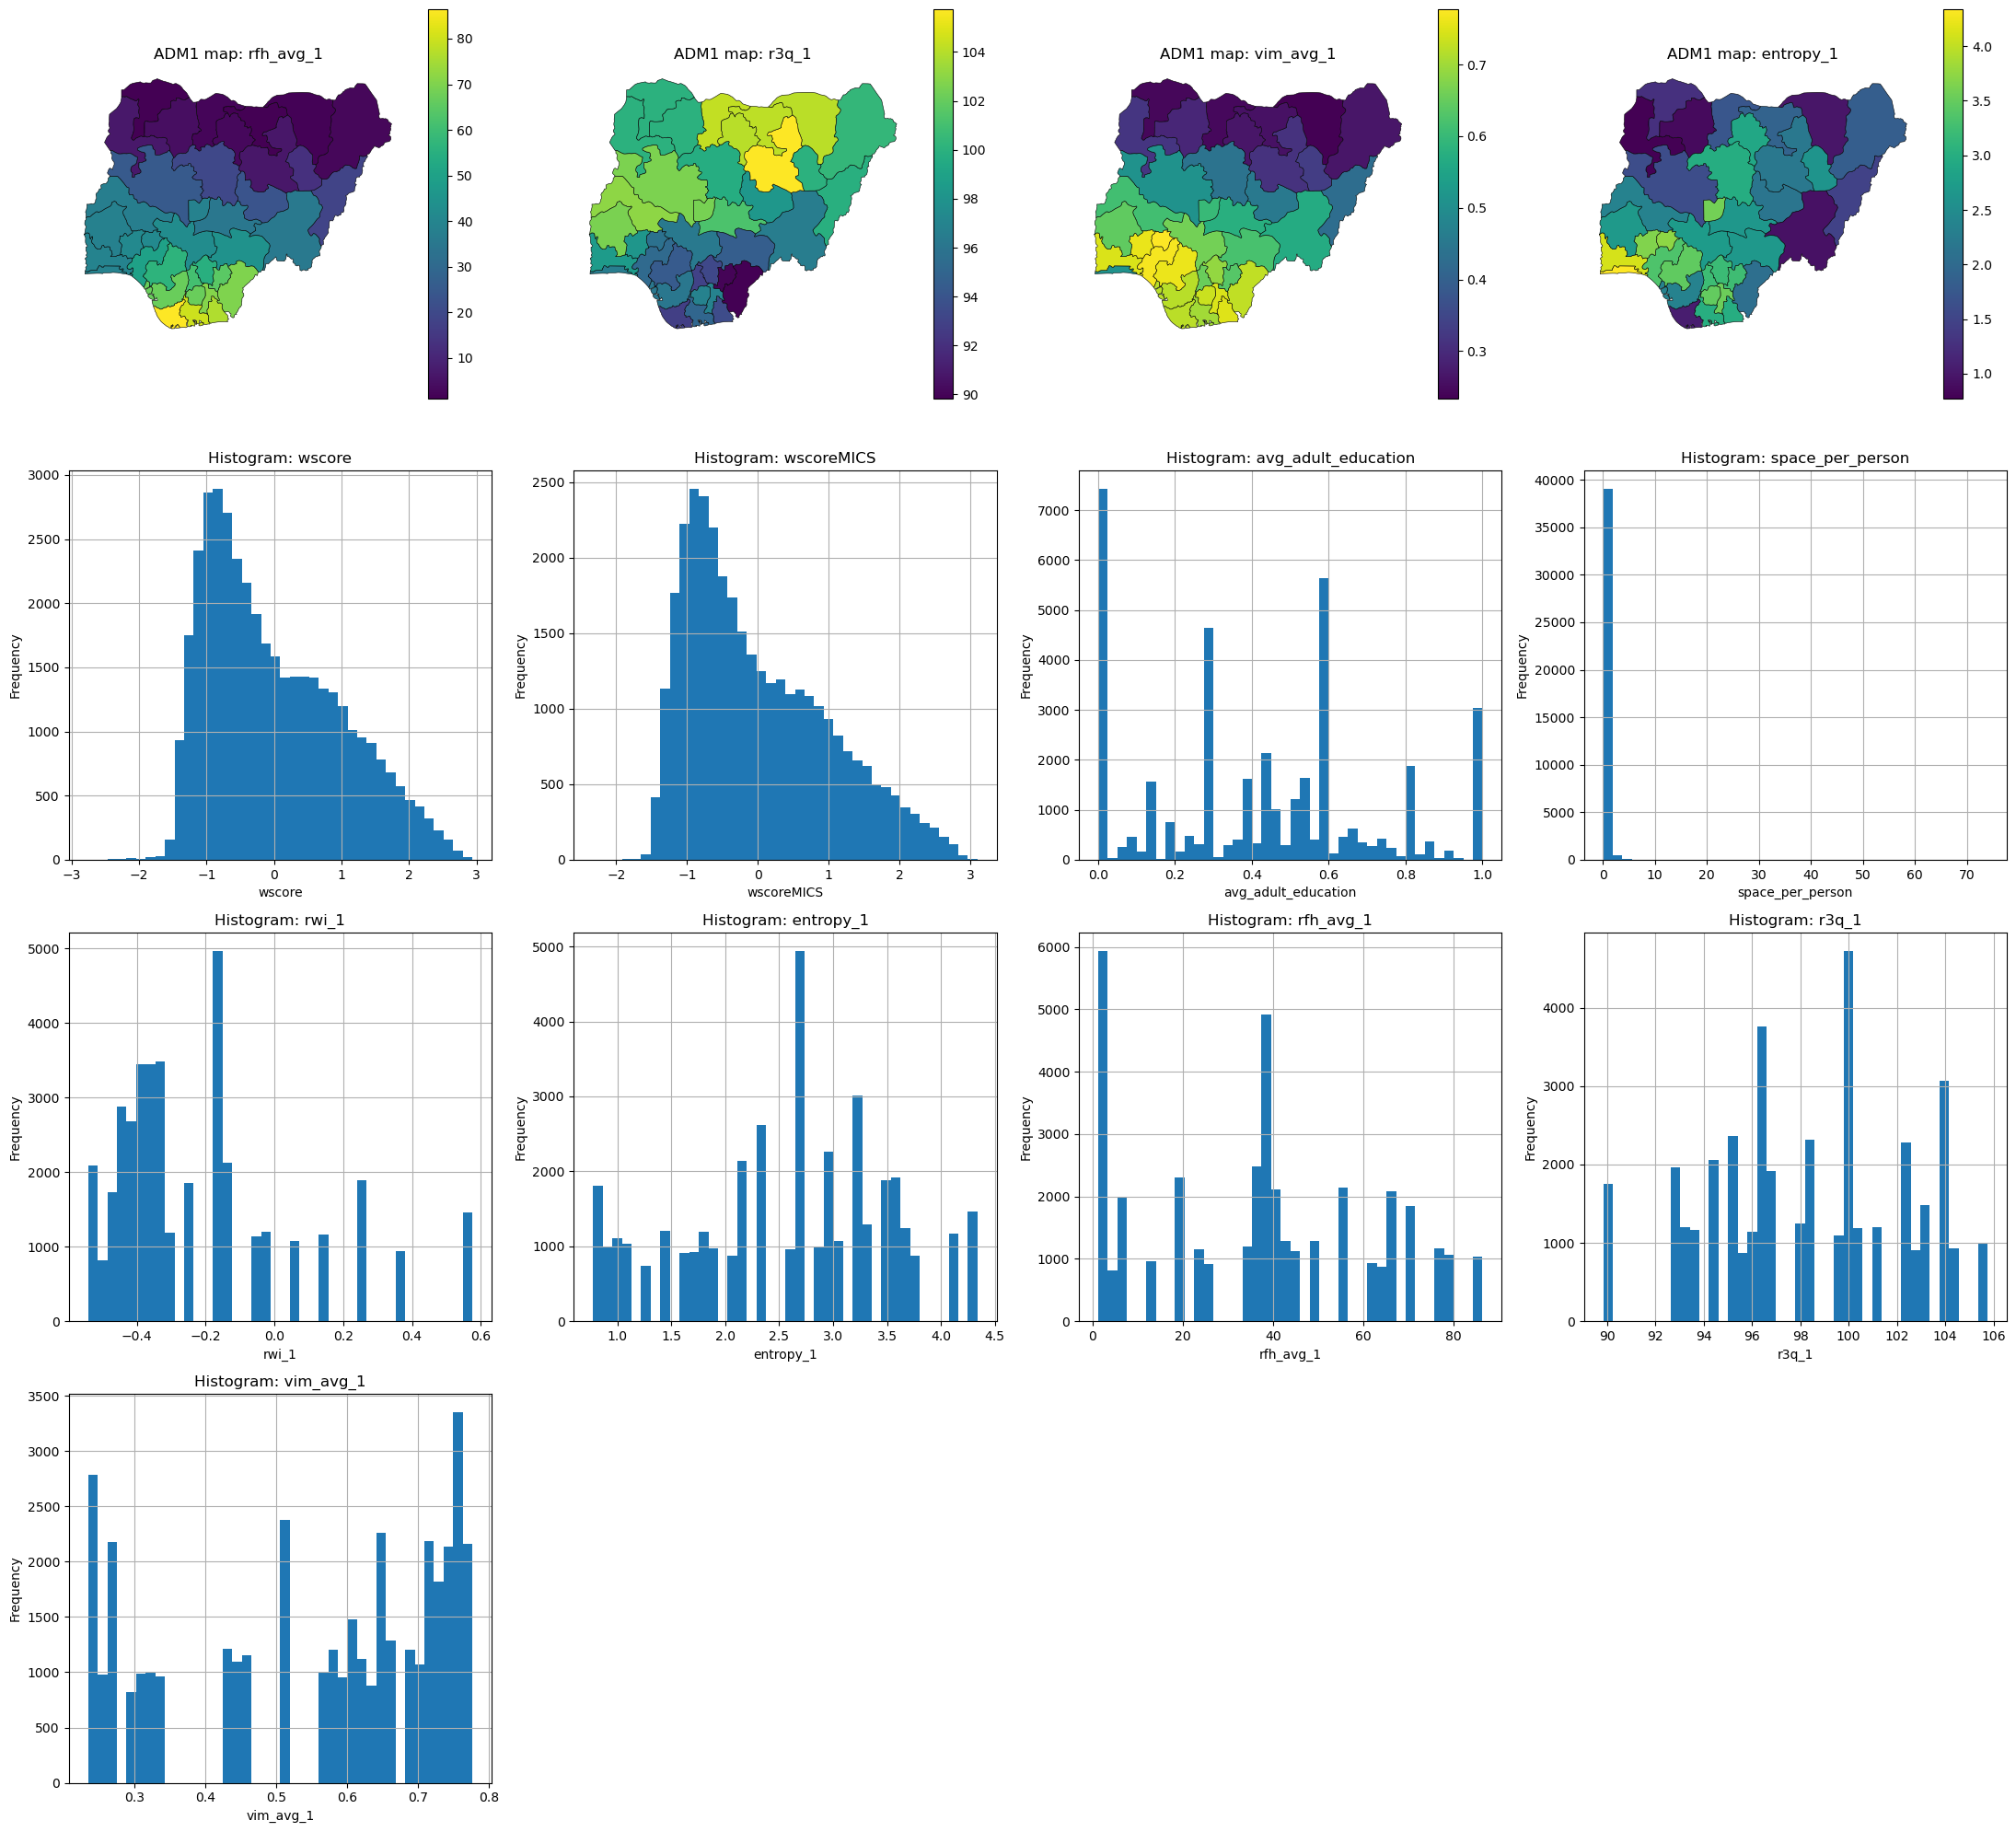

In [21]:
# One unique figure with:
# Row 1: ADM1 maps
# Row 2: ADM2 maps
# Then histograms below

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkt

plot_df = df_final.copy()

# Convert WKT geometries back to shapely geometries if needed
for geom_col in ["adm1geometry", "adm2geometry"]:
    if geom_col in plot_df.columns:
        plot_df[geom_col] = plot_df[geom_col].apply(
            lambda x: wkt.loads(x) if isinstance(x, str) else x
        )

# Variables to plot
adm1_map_vars = [
    "rfh_avg_1",
    "r3q_1",
    "vim_avg_1",
    "entropy_1",
    "rwi_1",
]

adm2_map_vars = [
    "rfh_avg_2",
    "r3q_2",
    "vim_avg_2",
    "entropy_2",
    "rwi_2",
]

hist_vars = [
    "wscore",
    "wscoreMICS",
    "avg_adult_education",
    "space_per_person",
    "rwi_1",
    "entropy_1",
    "rfh_avg_1",
    "r3q_1",
    "vim_avg_1",
]

adm1_map_vars = [c for c in adm1_map_vars if c in plot_df.columns]
adm2_map_vars = [c for c in adm2_map_vars if c in plot_df.columns]
hist_vars = [c for c in hist_vars if c in plot_df.columns]

# Build ADM1 GeoDataFrame if possible
adm1_gdf = None

if "adm1geometry" in plot_df.columns and adm1_map_vars:
    adm1_cols = ["adm1geometry"] + adm1_map_vars

    if "adm1name" in plot_df.columns:
        adm1_cols.insert(0, "adm1name")
    if "adm1code" in plot_df.columns:
        adm1_cols.insert(1 if "adm1name" in plot_df.columns else 0, "adm1code")

    adm1_gdf = (
        plot_df[adm1_cols]
        .drop_duplicates(subset=["adm1code"] if "adm1code" in plot_df.columns else ["adm1geometry"])
        .dropna(subset=["adm1geometry"])
        .copy()
    )

    adm1_gdf = gpd.GeoDataFrame(
        adm1_gdf,
        geometry="adm1geometry",
        crs="EPSG:4326"
    )

# Build ADM2 GeoDataFrame if possible
adm2_gdf = None

if "adm2geometry" in plot_df.columns and adm2_map_vars:
    adm2_cols = ["adm2geometry"] + adm2_map_vars

    if "adm2name" in plot_df.columns:
        adm2_cols.insert(0, "adm2name")
    if "adm2code" in plot_df.columns:
        adm2_cols.insert(1 if "adm2name" in plot_df.columns else 0, "adm2code")

    adm2_gdf = (
        plot_df[adm2_cols]
        .drop_duplicates(subset=["adm2code"] if "adm2code" in plot_df.columns else ["adm2geometry"])
        .dropna(subset=["adm2geometry"])
        .copy()
    )

    adm2_gdf = gpd.GeoDataFrame(
        adm2_gdf,
        geometry="adm2geometry",
        crs="EPSG:4326"
    )

# Layout settings
n_cols = 4
map_rows = 0

if adm1_gdf is not None and len(adm1_map_vars) > 0:
    map_rows += 1

if adm2_gdf is not None and len(adm2_map_vars) > 0:
    map_rows += 1

n_hist_cols = n_cols
n_hist_rows = int(np.ceil(len(hist_vars) / n_hist_cols)) if hist_vars else 0

total_rows = map_rows + n_hist_rows

if total_rows == 0:
    print("No ADM1/ADM2 maps or histograms available for plotting.")

else:
    fig, axes = plt.subplots(
        total_rows,
        n_cols,
        figsize=(22, 5 * total_rows)
    )

    axes = np.array(axes).reshape(total_rows, n_cols)

    # Turn all axes off first
    for ax in axes.ravel():
        ax.axis("off")

    current_row = 0

    # Row 1 — ADM1 maps
    if adm1_gdf is not None and len(adm1_map_vars) > 0:
        for i, col in enumerate(adm1_map_vars[:n_cols]):
            ax = axes[current_row, i]
            adm1_gdf.plot(
                column=col,
                ax=ax,
                legend=True,
                edgecolor="black",
                linewidth=0.4
            )
            ax.set_title(f"ADM1 map: {col}")
            ax.axis("off")

        current_row += 1

    # Row 2 — ADM2 maps
    if adm2_gdf is not None and len(adm2_map_vars) > 0:
        for i, col in enumerate(adm2_map_vars[:n_cols]):
            ax = axes[current_row, i]
            adm2_gdf.plot(
                column=col,
                ax=ax,
                legend=True,
                edgecolor="black",
                linewidth=0.2
            )
            ax.set_title(f"ADM2 map: {col}")
            ax.axis("off")

        current_row += 1

    # Histogram rows
    for i, col in enumerate(hist_vars):
        s = pd.to_numeric(plot_df[col], errors="coerce").dropna()

        if len(s) == 0:
            continue

        row = current_row + (i // n_hist_cols)
        col_pos = i % n_hist_cols

        ax = axes[row, col_pos]
        ax.axis("on")

        s.hist(bins=40, ax=ax)
        ax.set_title(f"Histogram: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")

    plt.tight_layout()

    # Save figure if BASE_OUT exists; otherwise just show it
    try:
        FIG_PATH = BASE_OUT / "maps_and_histograms.png"
        plt.savefig(FIG_PATH, dpi=300, bbox_inches="tight")

        print("Saved figure to:")
        print(FIG_PATH)

    except NameError:
        print("BASE_OUT is not defined, so the figure was not saved.")

    plt.show()